# импорт нужных библиотек


In [1]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import pandas as pd

# загрузка фото
разбиение на тензоры RGB
проверка размера

In [3]:
"""создал удобную функцию для изменения размера картинки"""
def do_resize(img, w=640, h=640):
    height, width, _ = img.shape
    print(f"исходный размер {width}x{height}")
    if w!=width and h!=height:
        new_img = cv2.resize(img, (w, h))
        height, width, _ = new_img.shape
        print(f"новый размер {width}x{height}")
        return new_img
    return img

In [4]:
"""уже читаем картинку через open-cv тоже для удобства"""
img = cv2.imread("hahaha.jpg")
img = do_resize(img, 640, 640)

исходный размер 735x490
новый размер 640x640


In [ ]:
"""поменял этот блок
поменял с BGR на RGB
сделал разбиение на матрицы  по другому"""
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
R, G, B = cv2.split(img)

print(R, G, B)


[[162 164 165 ... 162 162 162]
 [161 162 163 ... 162 161 162]
 [159 160 162 ... 164 161 163]
 ...
 [130 131 132 ... 154 152 155]
 [129 129 130 ... 151 150 151]
 [128 128 128 ... 150 150 150]] [[55 57 58 ... 57 56 56]
 [54 56 56 ... 57 55 56]
 [53 55 55 ... 57 54 56]
 ...
 [36 37 39 ... 54 53 55]
 [37 37 37 ... 51 52 52]
 [38 38 38 ... 52 52 52]] [[3 5 5 ... 5 6 4]
 [2 4 4 ... 4 4 5]
 [1 2 3 ... 4 4 6]
 ...
 [2 2 3 ... 6 2 3]
 [3 3 4 ... 6 4 3]
 [4 4 4 ... 8 7 5]]


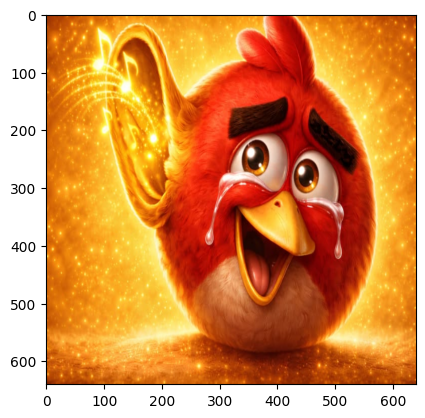

In [6]:
plt.imshow(img)

# степенной метод (пунтк №2)
формула сингулярного разложения: $A=UΣV^T$

In [7]:
def svd(A, singular_values, iter):
  U_cols, sigmas, V_cols = [], [], []
  A_curr = A.copy()

  for _ in range(singular_values):
    # random start vector
    v = np.random.randn(A_curr.shape[1])
    v = v / np.linalg.norm(v)

    # iterations
    for _ in range(iter):
      u = A_curr @ v
      sigma = np.linalg.norm(u)
      u = u / sigma
      v = A_curr.T @ u
      v = v / np.linalg.norm(v)

    U_cols.append(u)
    sigmas.append(sigma)
    V_cols.append(v)
    # вычитаем найденный вклад
    A_curr = A_curr - sigma * np.outer(u, v)

  return np.array(U_cols).T, np.array(sigmas), np.array(V_cols).T

# запуск сингулярного разложения степенным методом

In [8]:
def compare_iterations(channel, channel_name, k=200, iters=[10, 50, 100]):
    print(f'\nканал {channel_name}')
    for iter in iters:
        U, Z, V = svd(channel, k, iter)
        restored = U @ np.diag(Z) @ V.T
        error = np.linalg.norm(channel - restored)
        print(f"iter={iter}, ошибка={error:.4f}")

# запуск для всех трёх каналов
for ch, name in zip([R, G, B], ['R', 'G', 'B']):
    compare_iterations(ch, name)


канал R
iter=10, ошибка=643.0638
iter=50, ошибка=639.3612
iter=100, ошибка=639.3427

канал G
iter=10, ошибка=762.8037
iter=50, ошибка=759.0580
iter=100, ошибка=758.9255

канал B
iter=10, ошибка=768.0186
iter=50, ошибка=765.2504
iter=100, ошибка=765.3789


ошибка ||A - U∑$V^T$|| показывает насколько воссстановленная матрица отличается от оригинала

## результаты при k = 50:
  - канал R
  
    iter=10, ошибка=2987.7977

    iter=50, ошибка=2983.3460

    iter=100, ошибка=2983.3351

  - канал G
  
    iter=10, ошибка=4536.0334

    iter=50, ошибка=4530.5144

    iter=100, ошибка=4530.4962

  - канал B
  
    iter=10, ошибка=4670.6678

    iter=50, ошибка=4667.2234

    iter=100, ошибка=4667.2227

## результаты при k = 200:
  - канал R
  
    iter=10, ошибка=641.0911

    iter=50, ошибка=639.3838

    iter=100, ошибка=639.3423

  - канал G

    iter=10, ошибка=762.7475

    iter=50, ошибка=759.0092

    iter=100, ошибка=758.9513

  - канал B

    iter=10, ошибка=772.1471

    iter=50, ошибка=765.2477

    iter=100, ошибка=765.2356

### вывод по пункту 2:
1) ошибка падает в зависимости от кол-ва сингулярных чисел и кол-ва итераций (но эт не сильно влияет) ⇒ улучшается точность
  
!!! после 50 итераций ошибка почти сходится $\rightarrow$ увеличивать кол-во итераций (>100) не имеет смысла

2) различия между каналами:
  - R восстанавливается лучше остальных (наим ошибка)
  - B хуже всего 

# анализ сингулярных чисел и усеченное SVD (пунткт №3)

связь ошибки усеченного SVD со следующим сингулярным числом: $∥A−A_k​∥=\sigma_{k+1}​$

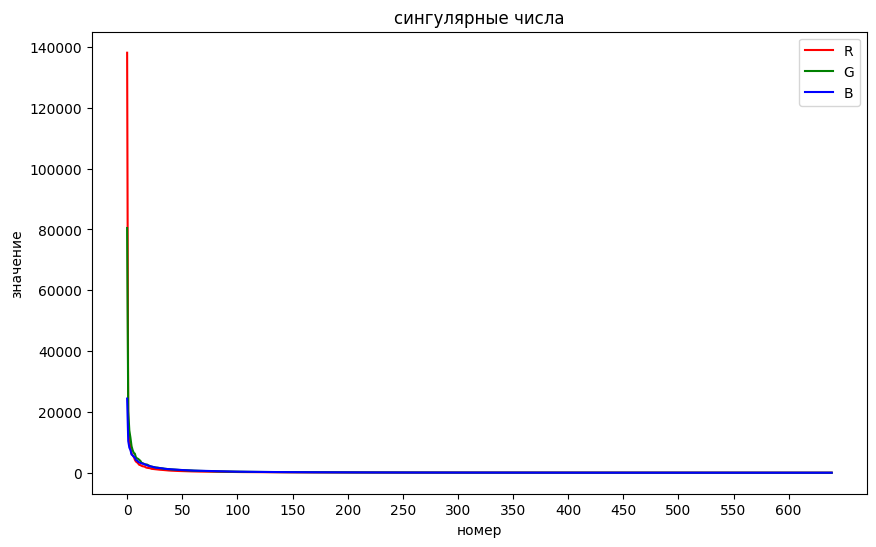

In [9]:
# get singular values
U_r, S_r, V_r = np.linalg.svd(R, full_matrices=False)
U_g, S_g, V_g = np.linalg.svd(G, full_matrices=False)
U_b, S_b, V_b = np.linalg.svd(B, full_matrices=False)

plt.figure(figsize=(10,6))
plt.plot(range(len(S_r)), S_r, color='red',label='R')
plt.plot(range(len(S_g)), S_g, color='green',label='G')
plt.plot(range(len(S_b)), S_b, color='blue',label='B')
plt.xticks(range(0, 640, 50))
plt.xlabel('номер')
plt.ylabel('значение')
plt.title('сингулярные числа')
plt.legend()
plt.show()

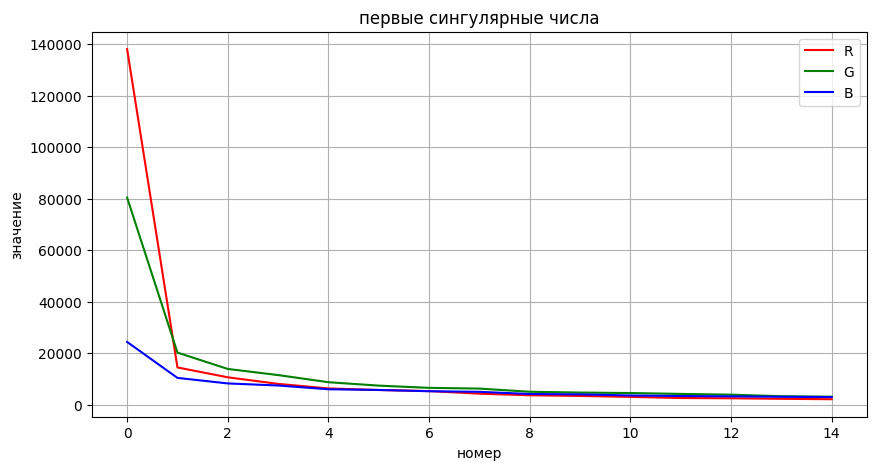

In [ ]:
"""добавил график для первых сингулярных чисел
чисто для наглядности"""
# ну тебе лайк
n = 15

plt.figure(figsize=(10, 5))

plt.plot(S_r[:n], label="R", color='red')
plt.plot(S_g[:n], label="G", color='green')
plt.plot(S_b[:n], label="B", color='blue')

plt.title("первые сингулярные числа")
plt.xlabel("номер")
plt.ylabel("значение")
plt.grid(True)
plt.legend()
plt.show()

### а) анализ графика
1) резкое падение в начале первые синг числа (<50) огромные (>80000), потом кривая обваливается ⇒ большая часть информации хранится в в первых нескольких компонентах

2) начиная с 50 номера кривая почти плоска, значения не меняются, т.е. их в клад в фотокарточку не значителен

3) все три канала ведут себя схоже, но R > G > B (в начале)

### б) предположить сколько нужно k
кривая резко убывает до 50, после практически не меняется. предположим, что k=range(0, 50) должно быть достаточно для приемлимого качества

### с) реализация усеченного разложения
$A_k =U_kΣ_kV^T_k , k ≪ min(n,m)$

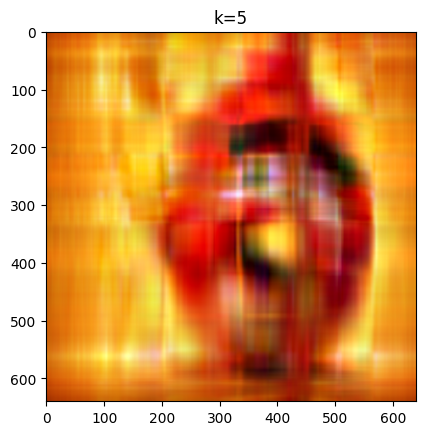

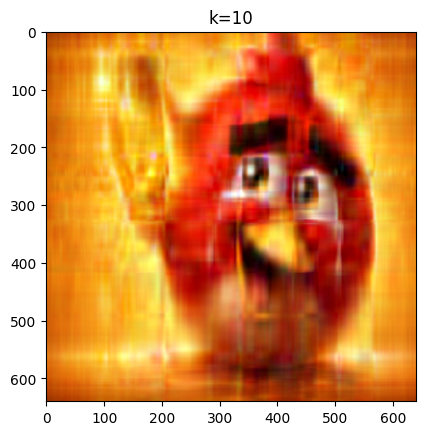

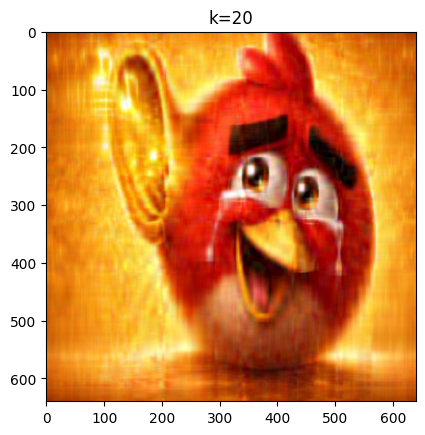

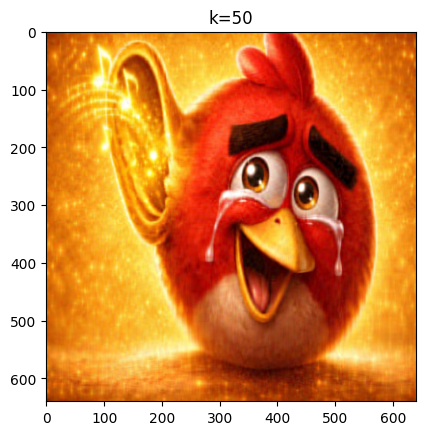

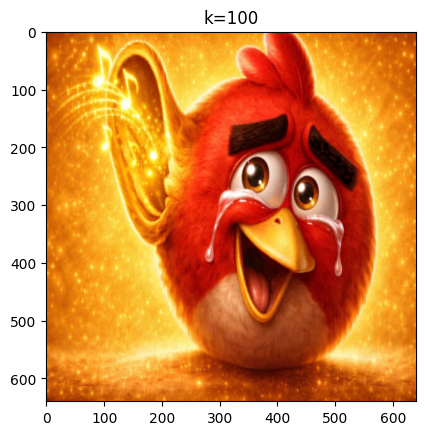

In [11]:
for k in [5, 10, 20, 50, 100]:
  R_k = U_r[:, :k]  @  np.diag(S_r[:k])  @  V_r[:k, :]
  G_k = U_g[:, :k]  @  np.diag(S_g[:k])  @  V_g[:k, :]
  B_k = U_b[:, :k]  @  np.diag(S_b[:k])  @  V_b[:k, :]

  img_restored = np.clip(np.stack([R_k, G_k, B_k], axis=2), 0, 255).astype(np.uint8)

  plt.figure()
  plt.title(f'k={k}')
  plt.imshow(img_restored)
  plt.show()

### d) вывод про картинку
картинка после восстановления стало визуально приемлимой на k=50
тк начиная с этого значения картинка визуально не отличается от оригинала, при этом объем данных значительно меньше

## Задание 4

- написал функцию ```calc_max_elem_without_diag``` которая считает максимальные числа выше диагонали и возвращает их индексы
- написал метод вращений Якоби `method_yakobi` который для симметричной 
матрицы B = $A^{T}A$
- сравнил вариант с свд и метод якоби
- сделал сравнительную таблицу
- $\epsilon=1e-6$

In [ ]:
def calc_max_elem_without_diag(B, eps=1e-6): # O(n^2)
    B = np.asarray(B, dtype=float)
    max_value = 0
    p = -1
    q = -1
    n = B.shape[0]

    for i in range(n): #O(n)
        for j in range(i + 1, n): # O(n)
            if abs(B[i, j]) > abs(max_value):
                max_value = B[i, j]
                p = i
                q = j
    if abs(max_value) < eps:
        return -1, -1

    return p, q
    
def method_yakobi(A,max_iter=1000, eps = 1e-6): # O(kn^3)
    A = np.asarray(A, dtype=float)
    B = A.T @ A
    B = B.astype(float)
    n = B.shape[0]
    for _ in range(max_iter): # O(k)
        p, q = calc_max_elem_without_diag(B) # O(n^2)
        if p ==-1 or q ==-1: # т.е закончились максимальные эелементы вне диагонали
            break
        if np.abs(B[p][q]) < eps:
            break

        r = (B[q][q] - B[p][p])/(2*B[p][q])
        if r >= 0:
            t = 1/((r) + np.sqrt(1 + r**2))
        else:
            t = -1/((-1*r) + np.sqrt(1 + r**2))
        c = 1/np.sqrt(1+t**2)
        s = t*c
        J = np.eye(n)
        J[p][p] = c
        J[q][q] = c
        J[p][q] = s
        J[q][p] = -s

        B = J.T @ B @ J # O(n^3)
    evals = np.diag(B)
    singulars = np.sqrt(evals)
    singulars = np.sort(singulars)[::-1]
    return singulars

In [ ]:
R, _, _ = cv2.split(img)
print(type(R))
print(R.shape)

<class 'numpy.ndarray'>
(640, 640)


In [14]:
# %timeit singulars = method_yakobi(R)
# %timeit  _, S_r, _ = np.linalg.svd(R, full_matrices=False)


In [15]:
singulars = method_yakobi(R)
_, S_r, _ = np.linalg.svd(R, full_matrices=False)

In [16]:
print(singulars.shape)
print(singulars[:20])

(640,)
[138111.07356284  14028.7907915    1615.45901636   1612.94559779
   1610.62231534   1609.73225125   1598.88534266   1597.58535345
   1578.88314678   1569.08002896   1564.8435146    1564.58542739
   1560.14371825   1559.67465772   1556.8571832    1555.42097309
   1553.04664954   1545.60339001   1544.09666199   1543.43853156]


In [17]:
compare = pd.DataFrame({
    "numpy_svd": S_r[:10],
    "yakobi": singulars[:10],
    "abs_diff": np.abs(S_r[:10]-singulars[:10])
})
compare

,numpy_svd,yakobi,abs_diff
0,138111.310702,138111.073563,0.237139
1,14480.321845,14028.790792,451.531054
2,10647.909267,1615.459016,9032.450250
3,8092.731549,1612.945598,6479.785951
4,6323.923544,1610.622315,4713.301228
5,5701.246939,1609.732251,4091.514688
6,5295.965240,1598.885343,3697.079897
7,4288.884123,1597.585353,2691.298769
8,3664.103936,1578.883147,2085.220789
9,3413.295769,1569.080029,1844.215741


## b) сравнение с пунктом 3

 - Степенной метод обычно находит только наибольшее сингулярное число
 - Метод Якоби находит все сингулярные числа, но работает тяжелее и дольше
 - результаты метода якоби совпадают (почти) для первых сингулярных чисел *(приемлемо)*

![Птица](bird.jpg)

## c) сравнение числа операций

- Степенной метод: O(k · N · m·n), где k=200, N=100, матрица 640×640 $\rightarrow$ ~8·10⁹ операций
- Метод Якоби: O(iter · n³), где iter=1000, n=640 $\rightarrow$ ~2.6·10¹¹ операций

# творческое задание (пункт 5)

## a) гистограмма распределения значений пикселей для каждого канала

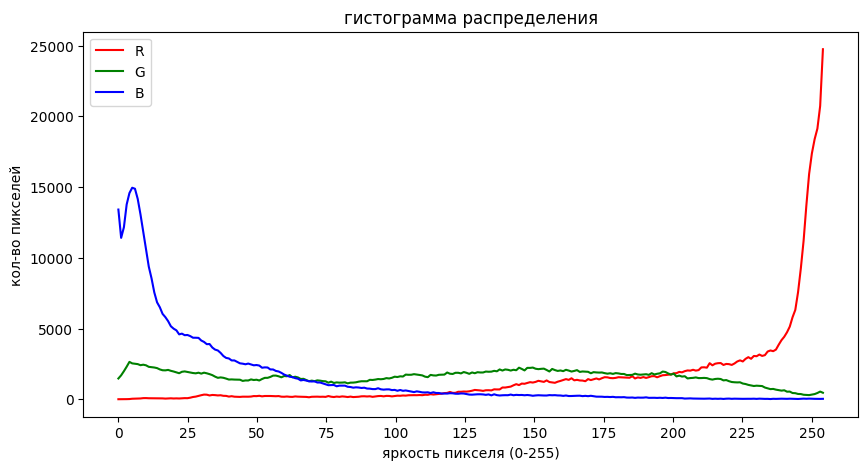

In [18]:
counts_r, bins_r = np.histogram(R.flatten(), bins=256, range=(0, 255))
counts_g, bins_g = np.histogram(G.flatten(), bins=256, range=(0, 255))
counts_b, bins_b = np.histogram(B.flatten(), bins=256, range=(0, 255))


plt.figure(figsize=(10, 5))
plt.plot(bins_r[:-1], counts_r, label='R', color='red')
plt.plot(bins_g[:-1], counts_g, label='G', color='green')
plt.plot(bins_b[:-1], counts_b, label='B', color='blue')

plt.xticks(range(0, 255, 25))
plt.title('гистограмма распределения')
plt.xlabel('яркость пикселя (0-255)')
plt.ylabel('кол-во пикселей')
plt.legend()
plt.show()

## анализ графика

  канал B:
   - пик в начале $\rightarrow$ много темно-синних оттеноков
   - резко убывает (яркость >100) $\rightarrow$ на фото много темных областей
  
  канал R:
   - пик в конце $\rightarrow$ много ярких пикселей в красном канале
  
  канал G:
   - распределен равномерно 

## b) как SVD влияет на распределение яркости

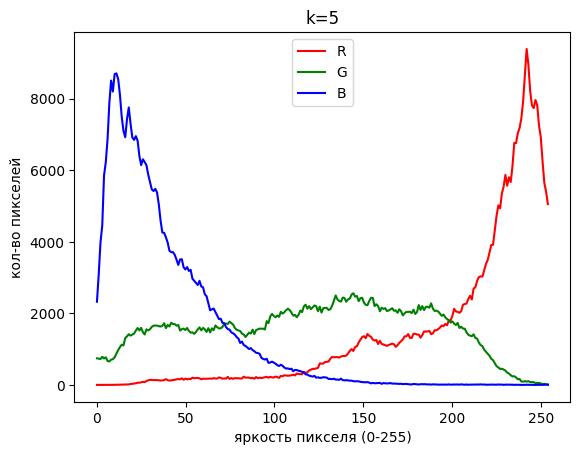

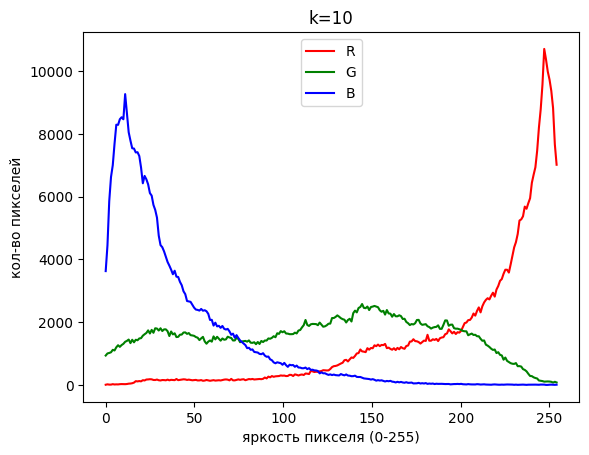

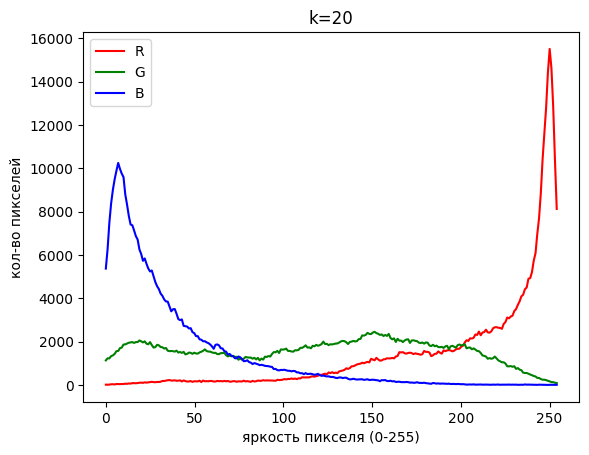

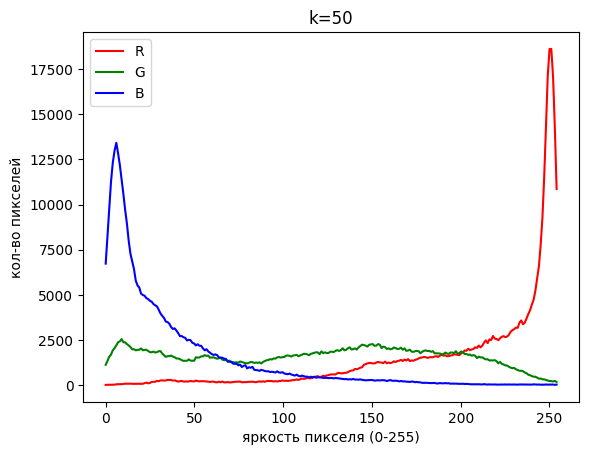

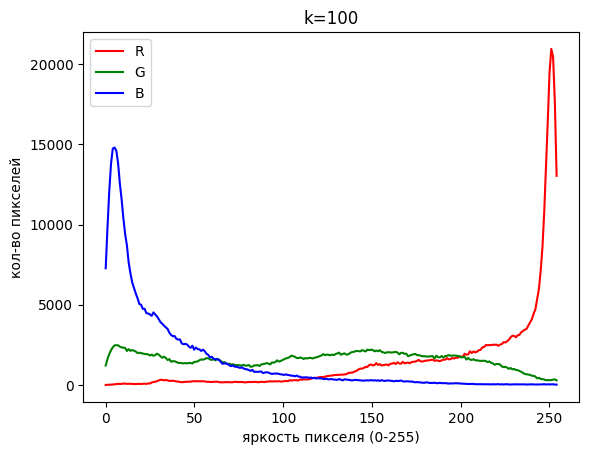

In [19]:
# цикл из пункта 3
for k in [5, 10, 20, 50, 100]:
  R_k = U_r[:, :k]  @  np.diag(S_r[:k])  @  V_r[:k, :]
  G_k = U_g[:, :k]  @  np.diag(S_g[:k])  @  V_g[:k, :]
  B_k = U_b[:, :k]  @  np.diag(S_b[:k])  @  V_b[:k, :]

  counts_r1, bins_r1 = np.histogram(R_k.flatten(), bins=256, range=(0, 255))
  counts_g1, bins_g1 = np.histogram(G_k.flatten(), bins=256, range=(0, 255))
  counts_b1, bins_b1 = np.histogram(B_k.flatten(), bins=256, range=(0, 255))

  plt.figure()
  plt.title(f'k={k}')

  plt.plot(bins_r1[:-1], counts_r1, label='R', color='red')
  plt.plot(bins_g1[:-1], counts_g1, label='G', color='green')
  plt.plot(bins_b1[:-1], counts_b1, label='B', color='blue')

  plt.xlabel('яркость пикселя (0-255)')
  plt.ylabel('кол-во пикселей')
  plt.legend()
  plt.show()

- при малых k (5, 10) распределение сглаживается

- гистограмма становится более равномерной

- при k > 50 распределение почти совпадает с оригиналом

вывод: SVD хорошо сохраняет яркостные хар-ки изобрадения при достаточном кол-ве компонент

## c) свой вариант использования

взять сингулярные числа $(\sum)$ от одного изображения и векторы направлений (U, V) от другого

формула обычного SVD:
$$A = U \Sigma V^T$$

в стилизации подменяем компоненты:
$$A_{styled} = U_{A} \cdot \Sigma_{B} \cdot V_{A}^T$$

где U, V берутся от изображения A (структура, контуры, направления), а $\sum$ берётся от изображения B (яркость, интенсивность).

что получим: U и V хранят информацию о *структуре* изображения - где края, где однородные области. $\sum$ хранит информацию об *интенсивности* - насколько яркие компоненты. Подменяя $\sum$, мы переносим "энергетический профиль" одного изображения на структуру другого - результат выглядит как стилизованная версия первого изображения с характером яркости второго.

исходный размер 622x623
новый размер 640x640


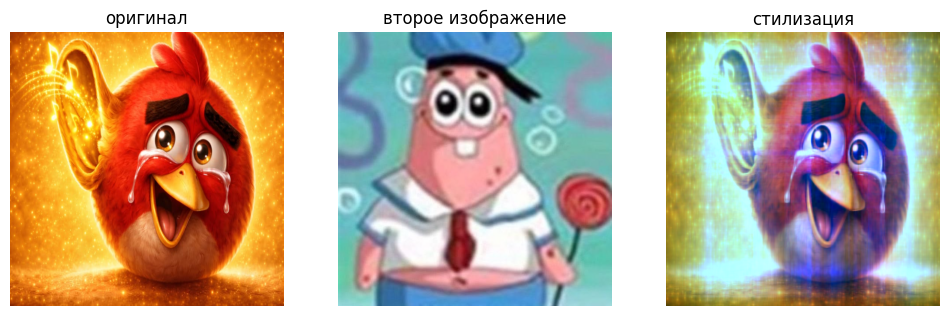

In [24]:
# загружаем второе изображение
img2 = cv2.imread('patric_kid.jpg')
img2 = do_resize(img2, 640, 640)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
R2, G2, B2 = cv2.split(img2)

# SVD для второго изображения
U_r2, S_r2, V_r2 = svd(R2, singular_values=200, iter=100)
U_g2, S_g2, V_g2 = svd(G2, singular_values=200, iter=100)
U_b2, S_b2, V_b2 = svd(B2, singular_values=200, iter=100)

# стилизация: U, V от первого, sigma от второго
R_styled = U_r[:, :200] @ np.diag(S_r2) @ V_r[:200, :]
G_styled = U_g[:, :200] @ np.diag(S_g2) @ V_g[:200, :]
B_styled = U_b[:, :200] @ np.diag(S_b2) @ V_b[:200, :]

img_styled = np.clip(np.stack([R_styled, G_styled, B_styled], axis=2), 0, 255).astype(np.uint8)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title('оригинал')
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('второе изображение')
plt.imshow(img2)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('стилизация')
plt.imshow(img_styled)
plt.axis('off')

plt.show()